In [2]:
# ============================================================
# Contrastive GNN Graph Embedding Training
# Small Connected ER Graphs (Weighted / Unweighted)
# ============================================================

import random
import numpy as np
import torch
from src.utils import read_config


In [3]:
# ------------------------
# IMPORTS
# ------------------------

import os
import networkx as nx
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.decomposition import PCA

from torch_geometric.data import Data, DataLoader
from torch_geometric.utils import from_networkx

import torch.nn as nn
import torch.nn.functional as F

from src.embedding.gnn_model import GNNGraphEncoder

In [4]:
config = read_config(path='config/config.yaml')
SEED = config['gnn']['SEED']

NUM_GRAPHS = config['gnn']['NUM_GRAPHS']
NODE_CHOICES = config['gnn']['NODE_CHOICES']
EDGE_P_MIN = config['gnn']['EDGE_P_MIN']
EDGE_P_MAX = config['gnn']['EDGE_P_MAX']

WEIGHT_UNIFORM_RANGE = config['gnn']['WEIGHT_UNIFORM_RANGE']
WEIGHTED_RATIO = config['gnn']['WEIGHTED_RATIO']

NODE_FEATURE_DIM = config['gnn']['NODE_FEATURE_DIM']

EMBEDDING_DIM = config['gnn']['EMBEDDING_DIM']
HIDDEN_DIM = config['gnn']['HIDDEN_DIM']
NUM_LAYERS = config['gnn']['NUM_LAYERS']

EPOCHS = config['gnn']['EPOCHS']
LR = float(config['gnn']['LR'])
WEIGHT_DECAY = float(config['gnn']['WEIGHT_DECAY'])
BATCH_SIZE = config['gnn']['BATCH_SIZE']

TEMPERATURE = config['gnn']['TEMPERATURE']

MODEL_PATH = config['gnn']['MODEL_PATH']


torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [7]:
# ------------------------
# GRAPH GENERATION
# ------------------------
def generate_connected_er_graph(weighted=True):
    n = random.choice(NODE_CHOICES)
    p = random.uniform(EDGE_P_MIN, EDGE_P_MAX)

    while True:
        G = nx.erdos_renyi_graph(n, p)
        if nx.is_connected(G):
            break

    for u, v in G.edges():
        if weighted:
            w = round(np.random.uniform(*WEIGHT_UNIFORM_RANGE), 2)
            while w == 0:
                w = round(np.random.uniform(*WEIGHT_UNIFORM_RANGE), 2)
            G[u][v]["weight"] = float(w)
        else:
            G[u][v]["weight"] = 1.0

    for node in G.nodes():
        G.nodes[node]["x"] = np.random.randn(NODE_FEATURE_DIM)

    return G


graphs = []
graph_types = []

for i in tqdm(range(NUM_GRAPHS), desc="Generating graphs"):
    weighted = random.random() < WEIGHTED_RATIO
    G = generate_connected_er_graph(weighted)
    graphs.append(G)
    graph_types.append(weighted)

print(f"Graphs: {NUM_GRAPHS} | Weighted: {sum(graph_types)}")

Generating graphs: 100%|██████████| 500/500 [00:00<00:00, 8325.37it/s]

Graphs: 500 | Weighted: 484


In [8]:
# ------------------------
# PyG DATASET
# ------------------------

data_list = []

for G in graphs:
    data = from_networkx(G)

    data.x = torch.tensor(
        np.vstack([G.nodes[n]["x"] for n in G.nodes()]),
        dtype=torch.float,
    )

    edge_weights = []
    for u, v in G.edges():
        w = G[u][v]["weight"]
        edge_weights.append(w)
        edge_weights.append(w)  # duplicate for (v, u)

    data.edge_weight = torch.tensor(edge_weights, dtype=torch.float)


    data_list.append(data)

loader = DataLoader(data_list, batch_size=BATCH_SIZE, shuffle=True)

/home/mrzaizai2k/anaconda3/envs/adapt_gpt/lib/python3.10/site-packages/torch_geometric/utils/convert.py:278: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  data_dict[key] = torch.as_tensor(value)
/tmp/ipykernel_81332/3664740197.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader = DataLoader(data_list, batch_size=BATCH_SIZE, shuffle=True)


In [6]:
def augment_graph(data, edge_drop_p=0.1, weight_noise=0.1, x_noise=0.1):
    data = data.clone()

    # Edge dropout
    if edge_drop_p > 0:
        num_edges = data.edge_index.size(1)
        mask = torch.rand(num_edges, device=data.edge_index.device) > edge_drop_p

        data.edge_index = data.edge_index[:, mask]
        if hasattr(data, "edge_weight"):
            data.edge_weight = data.edge_weight[mask]

    # Edge weight noise
    if hasattr(data, "edge_weight"):
        data.edge_weight = data.edge_weight * (
            1.0 + weight_noise * torch.randn_like(data.edge_weight)
        )

    # Node feature noise
    data.x = data.x + x_noise * torch.randn_like(data.x)

    return data


In [7]:
# ------------------------
# CONTRASTIVE LOSS
# ------------------------

def contrastive_loss(z1, z2, temperature=TEMPERATURE):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    logits = torch.mm(z1, z2.t()) / temperature
    labels = torch.arange(z1.size(0), device=z1.device)

    return F.cross_entropy(logits, labels)

In [8]:
# ------------------------
# MODEL + PROJECTION HEAD
# ------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

encoder = GNNGraphEncoder(
    in_dim=NODE_FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    embedding_dim=EMBEDDING_DIM,
    num_layers=NUM_LAYERS,
).to(device)

projector = nn.Sequential(
    nn.Linear(EMBEDDING_DIM, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
).to(device)

params = list(encoder.parameters()) + list(projector.parameters())

optimizer = torch.optim.Adam(params, lr=LR, weight_decay=WEIGHT_DECAY)

Device: cuda


In [9]:
# ------------------------
# TRAINING LOOP
# ------------------------

loss_history = []

encoder.train()
projector.train()

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)

        batch1 = augment_graph(batch)
        batch2 = augment_graph(batch)

        z1 = encoder(batch1.x, batch1.edge_index, batch1.batch)
        z2 = encoder(batch2.x, batch2.edge_index, batch2.batch)

        p1 = projector(z1)
        p2 = projector(z2)

        loss = contrastive_loss(p1, p2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:03d} | Contrastive Loss: {avg_loss:.4f}")

Epoch 002 | Contrastive Loss: 1.0163
Epoch 004 | Contrastive Loss: 0.8758
Epoch 006 | Contrastive Loss: 0.7670
Epoch 008 | Contrastive Loss: 0.7564
Epoch 010 | Contrastive Loss: 0.7057
Epoch 012 | Contrastive Loss: 0.7418
Epoch 014 | Contrastive Loss: 0.7230
Epoch 016 | Contrastive Loss: 0.7006
Epoch 018 | Contrastive Loss: 0.6590
Epoch 020 | Contrastive Loss: 0.7165


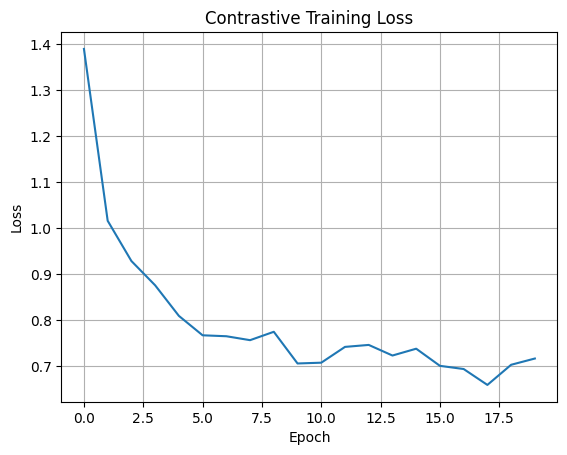

In [10]:
# ------------------------
# LOSS CURVE
# ------------------------

plt.plot(loss_history)
plt.title("Contrastive Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [11]:
# ------------------------
# SAVE ENCODER ONLY
# ------------------------

os.makedirs("models", exist_ok=True)
torch.save(encoder.state_dict(), MODEL_PATH)
print(f"Saved encoder to {MODEL_PATH}")

Saved encoder to models/gnn_graph_encoder_contrastive.pt


In [ ]:
# ------------------------
# LOAD ENCODER
# ------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

encoder = GNNGraphEncoder(
    in_dim=NODE_FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    embedding_dim=EMBEDDING_DIM,
    num_layers=NUM_LAYERS,
).to(device)

encoder.load_state_dict(torch.load(MODEL_PATH, map_location=device))
encoder = encoder.to(device)
encoder.eval()

print(f"Loaded encoder from {MODEL_PATH}")

# Experiments

In [ ]:
import networkx as nx
import torch
from torch_geometric.utils import from_networkx
from torch_geometric.loader import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_distances

# ------------------------
# GRAPH GENERATION
# ------------------------

def generate_connected_er_graph(n=10, p=0.3):
    while True:
        G = nx.erdos_renyi_graph(n, p)
        if nx.is_connected(G):
            break

    # add dummy features
    for i in G.nodes():
        G.nodes[i]["x"] = np.random.rand(4)

    for u, v in G.edges():
        G[u][v]["weight"] = np.random.rand()

    return G


def clone_graph(G):
    return nx.Graph(G)


def slight_modify(G):
    G_new = clone_graph(G)
    u, v = list(G_new.edges())[0]
    G_new.remove_edge(u, v)

    if not nx.is_connected(G_new):
        G_new.add_edge(u, v)

    return G_new


# ------------------------
# CREATE GRAPHS
# ------------------------

base_graph = generate_connected_er_graph()

graphs = [base_graph]
labels = ["Base"]
colors = ["blue"]

# 10 slightly different (green)
for i in range(10):
    g = slight_modify(base_graph)
    graphs.append(g)
    labels.append(f"Slight {i+1}")
    colors.append("green")

# 10 different graphs (red)
for i in range(10):
    g = generate_connected_er_graph()
    graphs.append(g)
    labels.append(f"Different {i+1}")
    colors.append("red")


# ------------------------
# CONVERT TO DATA
# ------------------------

data_list = []
for G in graphs:
    data = from_networkx(G)
    data.x = torch.tensor(
        [G.nodes[i]["x"] for i in G.nodes()],
        dtype=torch.float
    )
    data.edge_weight = torch.tensor(
        [G[u][v]["weight"] for u, v in G.edges()],
        dtype=torch.float
    )
    data_list.append(data)

loader = DataLoader(data_list, batch_size=len(data_list), shuffle=False)


# ------------------------
# GET EMBEDDINGS
# ------------------------

with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        emb = encoder(batch.x, batch.edge_index, batch.batch)

embeddings = emb.cpu().numpy()


# ------------------------
# DISTANCE MATRIX
# ------------------------

dist_matrix = cosine_distances(embeddings)


# ------------------------
# MDS (2D distance-preserving)
# ------------------------

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
emb_2d = mds.fit_transform(dist_matrix)


# ------------------------
# SCALE CONTROL (important!)
# ------------------------

# normalize to avoid "too far away"
scale = 3.0
emb_2d = emb_2d / np.max(np.abs(emb_2d)) * scale


/home/mrzaizai2k/anaconda3/envs/adapt_gpt/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


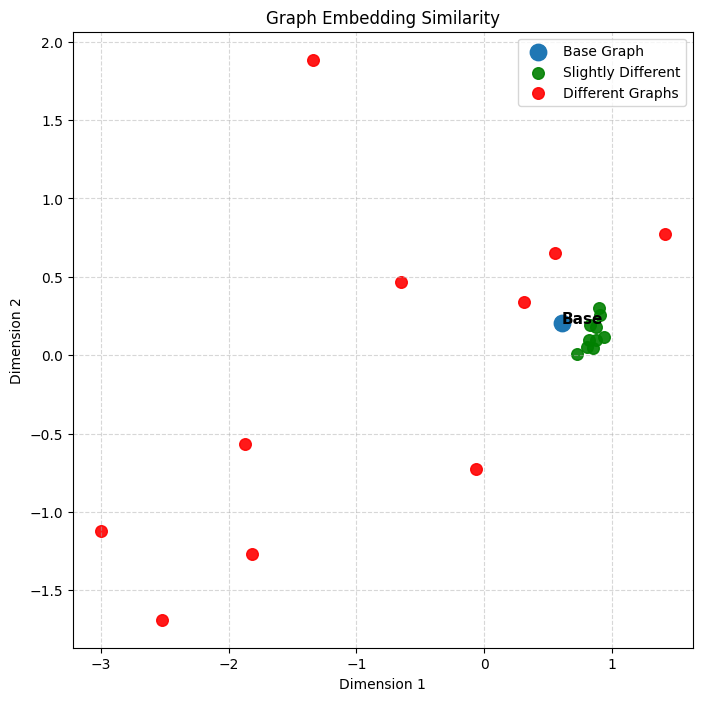

In [28]:
# ------------------------
# PLOT (with jitter for slight cluster)
# ------------------------

plt.figure(figsize=(8, 8))

base_idx = [0]
slight_idx = list(range(1, 11))
diff_idx = list(range(11, 21))

# --- BASE ---
plt.scatter(
    emb_2d[base_idx, 0],
    emb_2d[base_idx, 1],
    label="Base Graph",
    s=140,
    zorder=3
)

# --- SLIGHTLY DIFFERENT (random jitter, more natural) ---
slight_points = emb_2d[slight_idx]

# small random noise
noise_scale = 0.08   # 🔑 tune this (0.05–0.15 works well)
noise = np.random.normal(loc=0.0, scale=noise_scale, size=slight_points.shape)

jittered = slight_points + noise

plt.scatter(
    jittered[:, 0],
    jittered[:, 1],
    color="green",
    label="Slightly Different",
    s=70,
    alpha=0.9
)


# --- DIFFERENT ---
plt.scatter(
    emb_2d[diff_idx, 0],
    emb_2d[diff_idx, 1],
    color="red",
    label="Different Graphs",
    s=70,
    alpha=0.9
)

# annotate base
plt.text(
    emb_2d[0, 0],
    emb_2d[0, 1],
    "Base",
    fontsize=11,
    weight='bold'
)

plt.title("Graph Embedding Similarity")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()